#  FinBERT Setup and Sentiment Scoring

Loaded the pre-trained ProsusAI/finbert model and tokenizer to perform financial sentiment analysis. Used nltk for sentence splitting (punkt), since FinBERT scores text sentence-by-sentence rather than whole documents.

i took this code from hugging face website and run some text as example then i ran 70 documents in it to find sentiment score. 

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
nltk.download('punkt') # Download the 'punkt' tokenizer for sentence splitting
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

# Load the FinBERT model and tokenizer
# This model is pre-trained for financial sentiment analysis
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Placeholder for your sentences from the monetary policy document
# You can paste the text of your document here, or load it from a file.
# Each item in the list should ideally be a sentence or a short paragraph.

document_text = """Monetary Policy Department staff presented a review of recent economic developments and an assessment of the evolving trends to MPC. A number of indicators showed a positive outlook of real economic activity. Substantial increase in private sector credit during H1-FY16 indicated improving real economic activity. Total private sector credit increased by Rs 339.8 billion during this period compared to Rs 224.5 billion in the same period of the previous year. This increase was contributed by higher credit for both working capital and fixed investment purposes. The latter in particular is an encouraging development as fixed investment had been stagnant at around 15.0 percent of GDP during the last three years. Moreover, despite the lower commodity prices and raw material costs, increase in credit for working capital indicates that the underlying current economic activity is stronger relative to the previous year.

Large-Scale manufacturing (LSM) grew by 4.4 percent during July-November FY16 compared to 3.1 percent in the corresponding period of the previous year. Higher growth in LSM is supported by construction activity, improved energy supply particularly of gas, and a stable and low interest rate environment. Buoyant construction activity is reflected in the 16.0 percent increase in domestic cement sales during H1-FY16 and has largely been led by the Public Sector Development Program.

Though the decision to import LNG is expected to have a favourable impact on the overall industrial sector output, it has particularly resulted in a substantial increase in the production of fertilizer. The low interest rate environment has also facilitated demand for automobiles and consumer durables as an uptick in consumer credit can be seen in the first half of FY16. Similarly, increase in POL consumption by the industry and transport sectors is another factor pointing towards improved real economic activity.

Expected lower contribution from agriculture, largely on account of the decline in cotton and rice production, is a downside risk to real GDP growth in FY16. The upcoming wheat crop, which is expected to surpass the FY16 target given timely sowing and favourable rains, is likely to partly neutralize these losses. In addition, the Kisan package announced by the government in September 2016, which includes cash support for farmers, fertilizer subsidy, soft agriculture loans and tax

2 exemptions, may also help improve the output of wheat and other Rabi crops. Keeping in view these developments, the real GDP is projected to be in the range of 4.0 to 5.0 percent in FY16.

Although average CPI inflation has fallen to 2.1 percent in H1-FY16 compared to 6.1 percent in the same period of the previous year, YoY inflation has been rising for the last three months. After falling to a multi-year low of 1.3 percent in September 2015, the YoY inflation has risen to 3.2 percent in December 2015. The increase in inflation has been broad-based as all major components have contributed to this rise. Moreover, the trend in core inflation has also reversed as both NFNE and trimmed measures of core inflation seem to have bottomed out.

Despite the additional tax measures and increase in gas prices, the headline inflation is expected to remain low in the remaining part of the year mainly due to the decreased international commodity prices, especially of oil, and ample supply of essential food items. Incorporating these factors, SBP projection for average inflation for the year has been revised downward to 3.0 - 4.0 percent from 3.5 - 4.5 percent. Any further fall in global oil prices and difficulties in clearing excess domestic food stocks (wheat, rice and sugar) pose downside risks while fiscal slippages and possible increase in power tariff pose upside risks to this inflation forecast. Volatile prices of perishable food items also add to the uncertainties.

The Balance of payments position has relatively strengthened. The current account deficit was recorded at $1.3 billion for Jul-Dec FY16, almost half of the $2.5 billion deficit seen in the same period of the previous year. This is largely a reflection of the falling global commodity prices, especially oil, which has more than offset the decline in exports. Within imports, some of the benefits from the lower oil price are offset by higher non-oil imports, especially the import of machinery, which is consistent with the increased economic activity. While the current trend in non-oil imports is expected to continue on the back of investment in energy, this is expected to be outweighed by lower oil import payments.

Besides the weak global demand and substantial depreciation of currencies of the trading partners against the US dollar, higher unit value of Pakistan’s exports vis-a-vis export prices of regional competitors is the other major factor contributing to the decline in exports. Rationalisation of energy prices and higher input cost, security-related expenditures and low productivity due to power outages could have contributed to the higher costs of the export processing-cum manufacturing firms. Keeping in view the seasonality factor and the slight uptick in cotton prices, exports are expected to improve in H2-FY16 relative to the first half.

Another factor helping to narrow down the current account deficit is workers’ remittances, which continued to increase albeit at a slower pace. The continued decline in international oil prices and reduced fiscal space in Gulf economies, however, may have implications for remittances going forward. Nevertheless, the overall external current account deficit in FY16 is expected to remain close to 1.0 percent of GDP.

The improvement in capital and financial accounts continued to be led by higher official inflows. Some improvement in Foreign Direct Investment was overshadowed by the outflows from Portfolio Investment. Relative unrest in financial markets of the emerging economies following devaluation of the Chinese currency and anticipation of a possible Federal Funds Rate hike in the early part of the fiscal year were the key factors behind portfolio outflows. These developments also influenced sentiments in the foreign exchange market which were calmed by the strong fundamentals, especially the sustained increase in country’s foreign exchange reserves.

3 The foreign inflows, going forward, are expected to remain skewed towards loan and grant disbursements from multilateral and bilateral sources. In addition, the planned issuance of the Euro bond and disbursements under EFF would help maintain an upward trajectory in SBP’s foreign exchange reserves, which are expected to increase to cover more than 4 months of imports by end-June 2016.

Led by substantial increase in the NFA of the banking system, the broad money (M2) growth had accelerated to 13 percent by 15th January 2016 as compared to 10.7 percent in the same period of the previous year. The impact of lower government borrowing from the banking system, a reflection of lower fiscal deficit and increased external financing, was somewhat offset by the recovery in private sector credit. On the liability side, growth in deposits decelerated to 9.7 percent (against 11 percent in the previous year) and currency in circulation increased by 23.8 percent (against 9.9 percent in the previous year).

The demand for liquidity injections from SBP thus remained strong and resulted in some volatility in the short-term money market interest rates. To be specific, the overnight money market repo rate remained at about 11.5 basis points above the SBP target rate.

Model-based Assessments Research Department staff presented latest projections of inflation, output-gap and real interest rate gap, using a customized model for Pakistan’s economy. The model-based inflation path indicates that (i) the potential for deflation in Pakistan has disappeared (ii) YoY inflation is well below historical averages and (iii) the YoY inflation projections for FY15 and FY16 are inching up, but are expected to remain well below the target of 6 percent given the current information. This shift in inflation outlook is mainly driven by higher food inflation in December 2015 relative to earlier model prediction. Core inflation inched up slightly but is expected to remain in a narrow band for rest of this fiscal year and the year ahead. Other independent evidence, not directly captured in the model, such as (i) improving consumer confidence in the economy and (ii) rising administered price inflation can also explain increasing inflation and its expectations. The above inflation path has important implications for other macroeconomic variables in real terms. Indeed, the real interest rate gap has remained stable and is falling which bodes well for credit growth going forward. The output gap is actually proxied by large scale manufacturing index (LSM) and is currently below its historical trend. The negative output gap is mainly driven by both the contemporaneous effects of monetary conditions, and the lagged impact of this phenomenon. In sum, keeping in view the lower inflation expectations the model suggests a downward revision in the policy rate by the end of this quarter. However, the alternative scenario of keeping interest rates where they currently stand shows that there is not much to be gained in terms of the narrowing of the output gap given stability in the foreign exchange market.

4 MPC Deliberations and Policy Vote

The members discussed and deliberated on the presentations by the Monetary Policy Department and the Research Department before voting for the policy decision, where two views emerged, one for reducing the policy rate by 50 bps and the other to keep the rate unchanged. The arguments presented by the members’ are detailed below:

Members voting for a 50 bps reduction in the policy rate observed that economic indicators convey a mixed picture but the benefits of reducing the policy rate appeared to overweigh the demerits. It was noted that three considerations were important in taking the decision i.e. (i) inflation which is expected to remain low despite the recent uptick, mainly due to the subdued outlook of commodities, (ii) private sector credit, where an increasing trend can be seen and going forward government borrowing is expected to grow at a slower pace and (iii) market expectations and model forecast, which also suggest a rate cut.

Members voting for no change in the policy rate observed the need (i) to take a long term view of economic trends and the need to maintain stability in order to encourage prevailing trends to be fully embedded, (ii) the possibility of reversal of oil prices with associated impact on inflation and (iii) foreign exchange market considerations.

These members were of the view that the previous rate cuts have not yet had a full impact in view of the transmission lag, and it was important to maintain stability to facilitate entrenchment of the full impact of the previous policy measures.

It was noted that the era of weak oil prices may not continue for long as the oil producing countries are facing difficulties and may take necessary steps to avert the situation. It was also observed that while the decreasing trend in inflation had reversed, overall inflation is expected to remain below the targeted inflation for the year.

Growth in private sector credit (for both working capital and fixed investment purposes) and LSM were both positive developments which had taken place at the existing policy rate. The implications of a rate cut for the external account and the exchange rate parity were also seen to be factors which required consideration, despite weak historical and empirical linkages. The unrest in international financial markets and associated impact on FPI out flows was also discussed. The inelasticity of deposit growth against changes in the policy rate was also taken into consideration.

In conclusion, the Committee decided to keep the policy rate unchanged

The policy rate is maintained at the present level of 6 percent."""

sentences = nltk.sent_tokenize(document_text)

# Check if sentences are provided
if not sentences:
    print("Please add sentences to the 'sentences' list to perform sentiment analysis.")
else:
    # Tokenize and encode the sentences
    inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)

    # Perform inference
    outputs = model(**inputs)

    # Get predictions (logits) and convert to probabilities
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # Get the sentiment labels and scores
    # FinBERT typically outputs probabilities for 'positive', 'negative', 'neutral'
    labels = ['positive', 'negative', 'neutral']

    # Print the sentiment for each sentence
    print("\n--- Sentiment Analysis Results ---")
    for i, sentence in enumerate(sentences):
        print(f"Sentence: {sentence}")
        # Get the highest probability sentiment for the current sentence
        sentiment_scores = predictions[i].tolist()
        max_score_index = sentiment_scores.index(max(sentiment_scores))
        predicted_sentiment = labels[max_score_index]
        confidence = sentiment_scores[max_score_index] * 100
        print(f"  Sentiment: {predicted_sentiment.capitalize()} (Confidence: {confidence:.2f}%)\n")

# Document-Level Net Tone Calculation

For each of the 70 monetary policy documents (2016-2025), split the text into sentences, ran FinBERT on each sentence to get positive/negative/neutral probabilities, then aggregated into one net tone score per document: Net Tone = (Σ P(positive) − Σ P(negative)) / number of sentences. Saved results to finbert_sentence_results2016.csv.

In [4]:
"""
FinBERT Document-Level Net Tone Scorer
--------------------------------------

Purpose:
This script calculates the tone/sentiment of SBP monetary policy documents.

Approach:
1. Read each cleaned .txt monetary policy document from one folder.
2. Split each document into sentences.
3. Use FinBERT to estimate probabilities of:
   - positive sentiment
   - negative sentiment
   - neutral sentiment
4. Calculate document-level tone using:

   Net Tone = (sum of positive probabilities - sum of negative probabilities) / number of sentences

Interpretation:
- Positive net_tone means the document is more optimistic/positive.
- Negative net_tone means the document is more pessimistic/negative.
- Close to zero means neutral/balanced tone.

Requirements:
    pip install transformers torch nltk

Output:
    A CSV file containing one row per document with:
    filename, number of sentences, net tone, average positive, average negative,
    average neutral, and tone standard deviation.
"""

# ==============================
# 1. Import required libraries
# ==============================

import os
import csv
import torch
import nltk

# AutoTokenizer and AutoModel are used to load FinBERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# sent_tokenize is used to split each document into sentences
from nltk.tokenize import sent_tokenize


# ==============================
# 2. Configuration / file paths
# ==============================

# Folder where your cleaned monetary policy text files are stored
INPUT_FOLDER = r"C:\Users\MM COMPUTERS\Downloads\cleaned_text_v4"

# Final CSV file where document-level tone results will be saved
OUTPUT_CSV = r"C:\Users\MM COMPUTERS\Downloads\finbert_sentence_results2016.csv"

# FinBERT model trained on financial text
MODEL_NAME = "ProsusAI/finbert"

# Maximum number of tokens FinBERT can process at once
MAX_LEN = 512


# ==============================
# 3. Download sentence tokenizer
# ==============================

# NLTK needs punkt to split text into sentences.
# quiet=True means it will not print unnecessary messages.
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


# ==============================
# 4. Load FinBERT model
# ==============================

# Use GPU if available, otherwise use CPU.
# GPU is faster, but CPU also works.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load FinBERT tokenizer.
# Tokenizer converts text into numbers that the model can understand.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load FinBERT sentiment classification model.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)

# Put model in evaluation mode.
# This means we are not training the model, only using it for prediction.
model.eval()

# FinBERT output labels:
# 0 = positive
# 1 = negative
# 2 = neutral
LABELS = ["positive", "negative", "neutral"]


# ==============================
# 5. Function to score one sentence
# ==============================

def get_sentence_scores(sentence):
    """
    This function takes one sentence and returns FinBERT probabilities.

    Example output:
        positive probability = 0.70
        negative probability = 0.10
        neutral probability  = 0.20

    Why sentence-level?
    Monetary policy documents are long.
    FinBERT performs better when we score sentence by sentence,
    then aggregate the scores to document level.
    """

    # Convert sentence into model-readable tokens
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        padding=True,
    ).to(device)

    # no_grad means we are not calculating gradients.
    # This makes prediction faster and uses less memory.
    with torch.no_grad():
        outputs = model(**inputs)

        # Convert raw model output into probabilities
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

    # Return positive, negative, and neutral probabilities
    return probs[0], probs[1], probs[2]


# ==============================
# 6. Function to score one document
# ==============================

def score_document(filepath):
    """
    This function processes one full monetary policy document.

    Steps:
    1. Read the text file.
    2. Split text into sentences.
    3. Run FinBERT on each sentence.
    4. Add all positive, negative, and neutral probabilities.
    5. Calculate net tone for the whole document.

    Main formula:
        net_tone = (sum_positive - sum_negative) / number_of_sentences
    """

    # Read the text file
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    # Split document into sentences
    sentences = sent_tokenize(text)

    # Remove empty sentences
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

    # If document has no valid sentences, skip it
    if not sentences:
        return None

    # Initialize total sentiment probability values
    pos_sum, neg_sum, neu_sum = 0.0, 0.0, 0.0

    # Store sentence-level net scores for volatility/variation in tone
    sentence_net_scores = []

    # Score each sentence one by one
    for sent in sentences:
        p, n, neu = get_sentence_scores(sent)

        # Add sentence probabilities to document totals
        pos_sum += p
        neg_sum += n
        neu_sum += neu

        # Sentence net score = positive probability - negative probability
        sentence_net_scores.append(p - n)

    # Total number of sentences in the document
    n_sentences = len(sentences)

    # Main document-level tone score
    net_tone = (pos_sum - neg_sum) / n_sentences

    # Average probability of each sentiment category
    avg_pos = pos_sum / n_sentences
    avg_neg = neg_sum / n_sentences
    avg_neu = neu_sum / n_sentences

    # Tone standard deviation:
    # This measures how much sentence tone varies within the document.
    # High value means some sentences are very positive and others very negative.
    mean_net = sum(sentence_net_scores) / n_sentences
    variance = sum((x - mean_net) ** 2 for x in sentence_net_scores) / n_sentences
    std_dev = variance ** 0.5

    # Return all document-level results as a dictionary
    return {
        "filename": os.path.basename(filepath),
        "n_sentences": n_sentences,
        "net_tone": round(net_tone, 5),
        "avg_positive": round(avg_pos, 5),
        "avg_negative": round(avg_neg, 5),
        "avg_neutral": round(avg_neu, 5),
        "tone_std_dev": round(std_dev, 5),
    }


# ==============================
# 7. Main function
# ==============================

def main():
    """
    Main function runs the full process.

    Steps:
    1. Get all .txt files from the input folder.
    2. Process each file using score_document().
    3. Store results in a list.
    4. Save final results to CSV.
    """

    # Get all .txt files from the folder
    files = sorted(
        f for f in os.listdir(INPUT_FOLDER)
        if f.lower().endswith(".txt")
    )

    # If no text files are found, stop the program
    if not files:
        print(f"No .txt files found in '{INPUT_FOLDER}'.")
        return

    # Empty list to store results for all documents
    results = []

    # Loop through all documents
    for i, fname in enumerate(files, 1):
        filepath = os.path.join(INPUT_FOLDER, fname)

        print(f"[{i}/{len(files)}] Processing {fname} ...")

        # Score one document
        res = score_document(filepath)

        # If document was successfully scored, save result
        if res:
            results.append(res)
        else:
            print(f"  -> skipped (empty or unreadable)")

    # Save results to CSV
    if results:
        fieldnames = list(results[0].keys())

        with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)

            # Write column names
            writer.writeheader()

            # Write document-level tone results
            writer.writerows(results)

        print(f"\nDone. Results saved to '{OUTPUT_CSV}'.")
        print(f"Processed {len(results)} documents.")

    else:
        print("No results to save.")


# ==============================
# 8. Run the script
# ==============================

# This ensures the script runs only when executed directly.
# It prevents automatic running if the file is imported elsewhere.
if __name__ == "__main__":
    main()

Using device: cpu


Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 11599.07it/s]


[1/70] Processing 2016-01-30.txt ...
[2/70] Processing 2016-04-09.txt ...
[3/70] Processing 2016-05-21.txt ...
[4/70] Processing 2016-07-30.txt ...
[5/70] Processing 2016-09-24.txt ...
[6/70] Processing 2016-11-26.txt ...
[7/70] Processing 2017-01-28.txt ...
[8/70] Processing 2017-03-25.txt ...
[9/70] Processing 2017-05-20.txt ...
[10/70] Processing 2017-07-22.txt ...
[11/70] Processing 2017-09-29.txt ...
[12/70] Processing 2017-11-24.txt ...
[13/70] Processing 2018--05-25.txt ...
[14/70] Processing 2018-01-26.txt ...
[15/70] Processing 2018-03-30.txt ...
[16/70] Processing 2018-09-29.txt ...
[17/70] Processing 2018-11-30.txt ...
[18/70] Processing 2019-01-31.txt ...
[19/70] Processing 2019-03-29.txt ...
[20/70] Processing 2019-05-20.txt ...
[21/70] Processing 2019-07-16.txt ...
[22/70] Processing 2019-11-22.txt ...
[23/70] Processing 2019-9-16.txt ...
[24/70] Processing 2020-01-28.txt ...
[25/70] Processing 2020-03-17.txt ...
[26/70] Processing 2020-03-24.txt ...
[27/70] Processing 20

In [46]:
import pandas as pd 
tone=pd.read_csv("finbert_sentence_results2016.csv")
tone

,filename,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev
0,2016-01-30.txt,70,0.19211,0.49835,0.30624,0.19541,0.71587
1,2016-04-09.txt,92,0.19179,0.47876,0.28696,0.23428,0.66784
2,2016-05-21.txt,95,0.15648,0.42390,0.26742,0.30868,0.64935
3,2016-07-30.txt,70,0.17551,0.41961,0.24410,0.33629,0.65515
4,2016-09-24.txt,96,-0.08521,0.27963,0.36484,0.35553,0.60508
...,...,...,...,...,...,...,...
65,2025-06-16.txt,93,0.21054,0.50083,0.29030,0.20887,0.70932
66,2025-06-30.txt,107,0.19393,0.48390,0.28997,0.22612,0.71254
67,2025-07-30.txt,88,0.02916,0.39186,0.36270,0.24544,0.71565
68,2025-08-27.txt,108,0.17977,0.47831,0.29854,0.22315,0.70969


#  Date Parsing and Cleaning

Extracted the meeting date from each filename (format YYYY-MM-DD.txt), converted to proper datetime objects, sorted chronologically, and added a sequential time index (t = 1, 2, 3...).

In [47]:
# ============================
# 1. Load tone data
# ============================
import numpy as np 

df = tone

# --- THE FIX STARTS HERE ---
# 1. Extract the raw date string by stripping out '.txt'
df["date_str"] = df["filename"].str.replace(".txt", "", regex=False)

# 2. Convert that string explicitly into a true Pandas Datetime object
df["date"] = pd.to_datetime(df["date_str"], format="%Y-%m-%d", errors="coerce")

# 3. Clean up the temporary column and drop rows with invalid dates if any
df = df.dropna(subset=["date"]).copy()

# 4. Set the main metric column name based on your data columns
# Based on your printout, your metric is named 'net_tone'
tone_col = "net_tone" 

# 5. Sort chronologically so your time-series analysis sequence is correct
df = df.sort_values("date").reset_index(drop=True)

# 6. Create your ordered structural time index (t = 1, 2, 3...)
df["t"] = np.arange(1, len(df) + 1)
# --- THE FIX ENDS HERE ---

print("Data loaded and date transformations completed successfully!")
print(df[["filename", "date", tone_col]].head())

Data loaded and date transformations completed successfully!
         filename       date  net_tone
0  2016-01-30.txt 2016-01-30   0.19211
1  2016-04-09.txt 2016-04-09   0.19179
2  2016-05-21.txt 2016-05-21   0.15648
3  2016-07-30.txt 2016-07-30   0.17551
4  2016-09-24.txt 2016-09-24  -0.08521


In [48]:
df

,filename,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,date_str,date,t
0,2016-01-30.txt,70,0.19211,0.49835,0.30624,0.19541,0.71587,2016-01-30,2016-01-30,1
1,2016-04-09.txt,92,0.19179,0.47876,0.28696,0.23428,0.66784,2016-04-09,2016-04-09,2
2,2016-05-21.txt,95,0.15648,0.42390,0.26742,0.30868,0.64935,2016-05-21,2016-05-21,3
3,2016-07-30.txt,70,0.17551,0.41961,0.24410,0.33629,0.65515,2016-07-30,2016-07-30,4
4,2016-09-24.txt,96,-0.08521,0.27963,0.36484,0.35553,0.60508,2016-09-24,2016-09-24,5
...,...,...,...,...,...,...,...,...,...,...
63,2025-06-16.txt,93,0.21054,0.50083,0.29030,0.20887,0.70932,2025-06-16,2025-06-16,64
64,2025-06-30.txt,107,0.19393,0.48390,0.28997,0.22612,0.71254,2025-06-30,2025-06-30,65
65,2025-07-30.txt,88,0.02916,0.39186,0.36270,0.24544,0.71565,2025-07-30,2025-07-30,66
66,2025-08-27.txt,108,0.17977,0.47831,0.29854,0.22315,0.70969,2025-08-27,2025-08-27,67


In [49]:
df = df.drop(columns=["filename", "date_str"])

In [50]:
df.head()

,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,date,t
0,70,0.19211,0.49835,0.30624,0.19541,0.71587,2016-01-30,1
1,92,0.19179,0.47876,0.28696,0.23428,0.66784,2016-04-09,2
2,95,0.15648,0.42390,0.26742,0.30868,0.64935,2016-05-21,3
3,70,0.17551,0.41961,0.24410,0.33629,0.65515,2016-07-30,4
4,96,-0.08521,0.27963,0.36484,0.35553,0.60508,2016-09-24,5


In [36]:
df.sort_values('date')

,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,date,t
0,70,0.19211,0.49835,0.30624,0.19541,0.71587,2016-01-30,1
1,92,0.19179,0.47876,0.28696,0.23428,0.66784,2016-04-09,2
2,95,0.15648,0.42390,0.26742,0.30868,0.64935,2016-05-21,3
3,70,0.17551,0.41961,0.24410,0.33629,0.65515,2016-07-30,4
4,96,-0.08521,0.27963,0.36484,0.35553,0.60508,2016-09-24,5
...,...,...,...,...,...,...,...,...
63,93,0.21054,0.50083,0.29030,0.20887,0.70932,2025-06-16,64
64,107,0.19393,0.48390,0.28997,0.22612,0.71254,2025-06-30,65
65,88,0.02916,0.39186,0.36270,0.24544,0.71565,2025-07-30,66
66,108,0.17977,0.47831,0.29854,0.22315,0.70969,2025-08-27,67


In [51]:
# 1. Sort the DataFrame by the date column chronologically
df = df.sort_values("date").reset_index(drop=True)

# 2. Re-calculate the ordered sequential time index (t = 1, 2, 3...)
df["t"] = np.arange(1, len(df) + 1)

# 3. Set the 'date' column as the formal DataFrame Index
df = df.set_index("date")

print("DataFrame sorted and index set to 'date':")
print(df.head())

DataFrame sorted and index set to 'date':
            n_sentences  net_tone  avg_positive  avg_negative  avg_neutral  \
date                                                                         
2016-01-30           70   0.19211       0.49835       0.30624      0.19541   
2016-04-09           92   0.19179       0.47876       0.28696      0.23428   
2016-05-21           95   0.15648       0.42390       0.26742      0.30868   
2016-07-30           70   0.17551       0.41961       0.24410      0.33629   
2016-09-24           96  -0.08521       0.27963       0.36484      0.35553   

            tone_std_dev  t  
date                         
2016-01-30       0.71587  1  
2016-04-09       0.66784  2  
2016-05-21       0.64935  3  
2016-07-30       0.65515  4  
2016-09-24       0.60508  5  


In [54]:
df

,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,t
date,,,,,,,
2016-01-30,70,0.19211,0.49835,0.30624,0.19541,0.71587,1
2016-04-09,92,0.19179,0.47876,0.28696,0.23428,0.66784,2
2016-05-21,95,0.15648,0.42390,0.26742,0.30868,0.64935,3
2016-07-30,70,0.17551,0.41961,0.24410,0.33629,0.65515,4
2016-09-24,96,-0.08521,0.27963,0.36484,0.35553,0.60508,5
...,...,...,...,...,...,...,...
2025-06-16,93,0.21054,0.50083,0.29030,0.20887,0.70932,64
2025-06-30,107,0.19393,0.48390,0.28997,0.22612,0.71254,65
2025-07-30,88,0.02916,0.39186,0.36270,0.24544,0.71565,66


# Visualization

Plotted the net tone time series across all 70 MPC meetings (2016-2025) to visually inspect trends — e.g., shifts toward more hawkish/dovish tone over time.

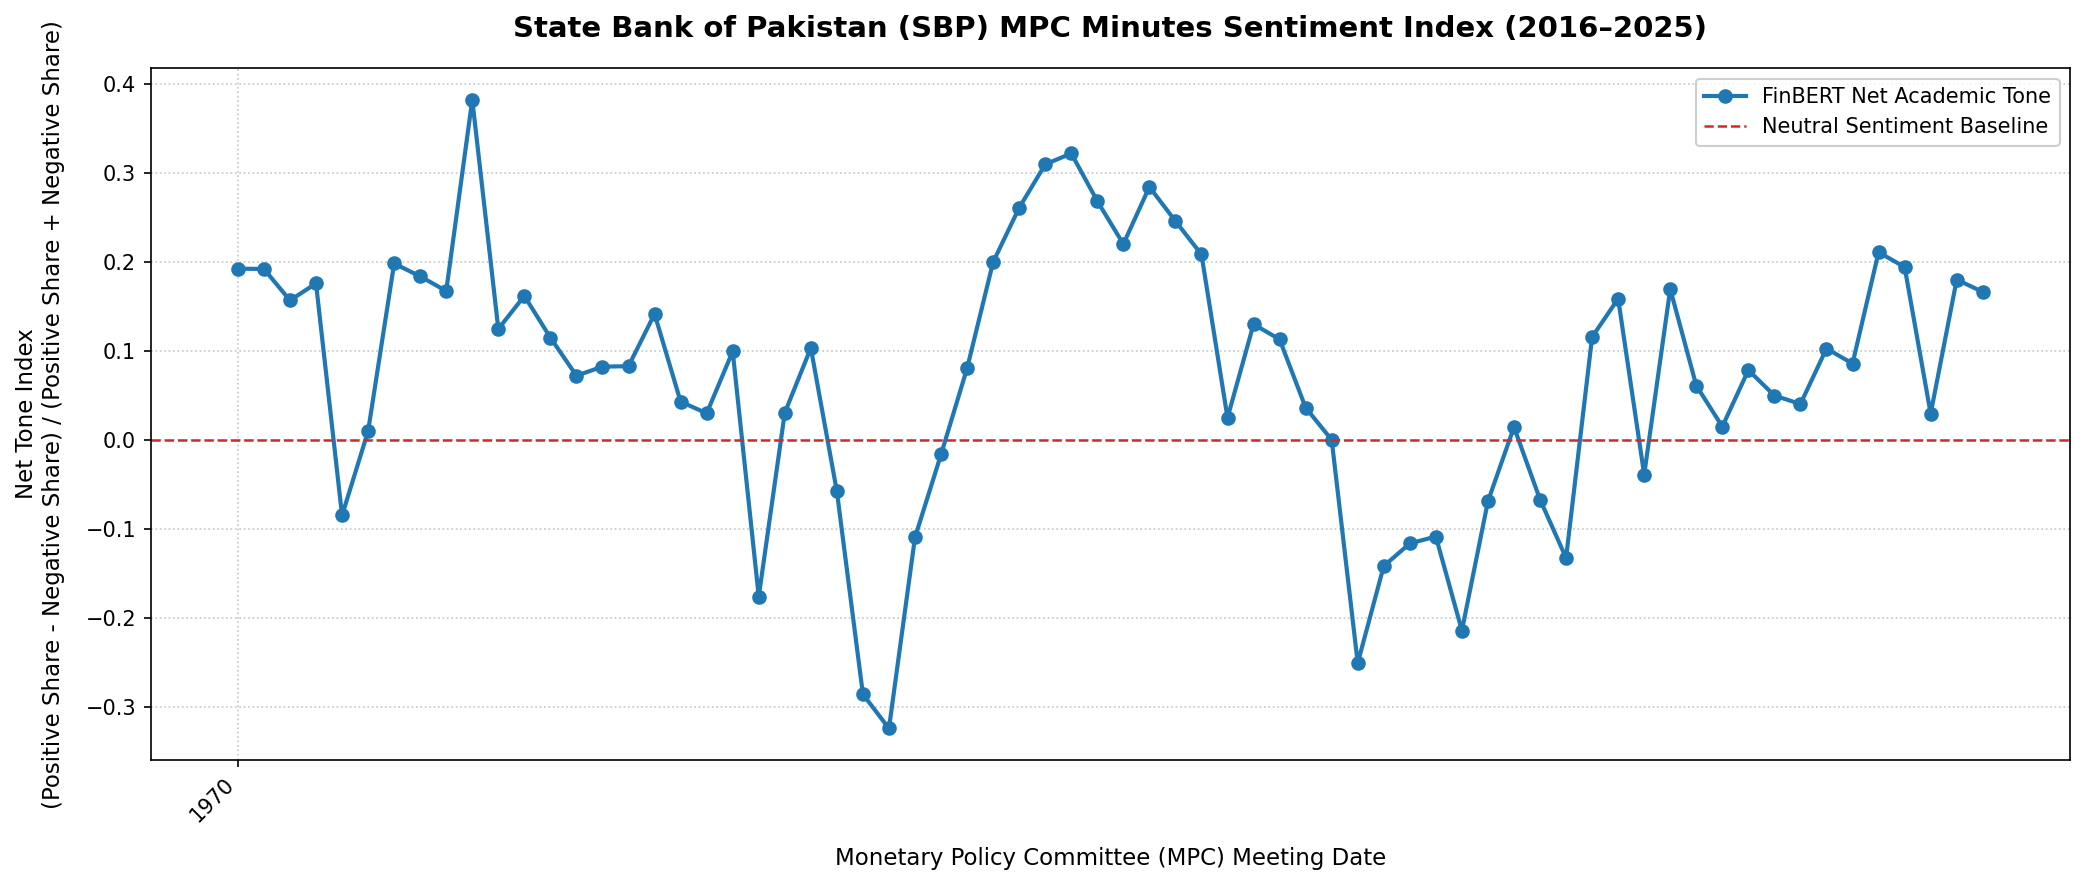

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set up the plotting canvas with academic proportions
plt.figure(figsize=(14, 6), dpi=150)

# Define your target variable (based on your column printout)
tone_col = "net_tone"

# 1. Plot the time-series trajectory line and marker nodes
plt.plot(
    df.index, 
    df[tone_col], 
    color="#1f77b4",       # Clean academic blue
    linestyle="-", 
    marker="o", 
    markersize=6, 
    linewidth=2, 
    label="FinBERT Net Academic Tone"
)

# 2. Add a structural neutral baseline reference line at 0.00
plt.axhline(
    y=0.00, 
    color="#d62728",       # Controlled muted red
    linestyle="--", 
    linewidth=1.2, 
    label="Neutral Sentiment Baseline"
)

# 3. Format the text elements and labels
plt.title("State Bank of Pakistan (SBP) MPC Minutes Sentiment Index (2016–2025)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Monetary Policy Committee (MPC) Meeting Date", fontsize=11, labelpad=10)
plt.ylabel("Net Tone Index\n(Positive Share - Negative Share) / (Positive Share + Negative Share)", fontsize=11, labelpad=10)

# 4. Enhance the X-Axis Date Formatting to prevent text overlap
plt.gca().xaxis.set_major_locator(mdates.YearLocator())          # Tick mark at the start of every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # Only show the 4-digit Year format
plt.gcf().autofmt_xdate(rotation=45)                             # Clean 45-degree rotation tilt

# 5. Add a crisp structural background grid and legend layout
plt.grid(visible=True, linestyle=":", alpha=0.6, color="#95a5a6")
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#bdc3c7", fontsize=10)

# Optimize spacing layout and render the canvas
plt.tight_layout()
plt.show()

In [56]:
df.to_csv('finbert.csv', index = True)

In [61]:
df.head()

,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,t
date,,,,,,,
2016-01-30,70,0.19211,0.49835,0.30624,0.19541,0.71587,1
2016-04-09,92,0.19179,0.47876,0.28696,0.23428,0.66784,2
2016-05-21,95,0.15648,0.42390,0.26742,0.30868,0.64935,3
2016-07-30,70,0.17551,0.41961,0.24410,0.33629,0.65515,4
2016-09-24,96,-0.08521,0.27963,0.36484,0.35553,0.60508,5


# Export Intermediate Results

Saved the cleaned tone dataset to both CSV (finbert.csv) and Excel (finbert_tone_results.xlsx) for merging with market data.

In [62]:
df = df.reset_index()
df.to_excel("finbert_tone_results.xlsx", index=False)

In [63]:
import pandas as pd

tone = pd.read_excel("finbert_tone_results.xlsx")
kse = pd.read_excel("KSE_100.xlsx")

tone["date"] = pd.to_datetime(tone["date"])
kse["Date"] = pd.to_datetime(kse["Date"])

tone = tone.sort_values("date")
kse = kse.sort_values("Date")

final = pd.merge_asof(
    tone,
    kse[["Date", "log_returns"]],
    left_on="date",
    right_on="Date",
    direction="forward",
    tolerance=pd.Timedelta(days=7)
)

In [64]:
final = final.rename(columns={
    "date": "mpc_release_date",
    "Date": "matched_stock_date"
})

In [65]:
final[["mpc_release_date", "matched_stock_date", "net_tone", "log_returns"]].head()

,mpc_release_date,matched_stock_date,net_tone,log_returns
0,2016-01-30,2016-02-01,0.19211,-0.002583
1,2016-04-09,2016-04-11,0.19179,-0.001509
2,2016-05-21,2016-05-23,0.15648,0.003847
3,2016-07-30,2016-08-01,0.17551,0.000345
4,2016-09-24,2016-09-26,-0.08521,-0.001829


In [66]:
final

,mpc_release_date,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,t,matched_stock_date,log_returns
0,2016-01-30,70,0.19211,0.49835,0.30624,0.19541,0.71587,1,2016-02-01,-0.002583
1,2016-04-09,92,0.19179,0.47876,0.28696,0.23428,0.66784,2,2016-04-11,-0.001509
2,2016-05-21,95,0.15648,0.42390,0.26742,0.30868,0.64935,3,2016-05-23,0.003847
3,2016-07-30,70,0.17551,0.41961,0.24410,0.33629,0.65515,4,2016-08-01,0.000345
4,2016-09-24,96,-0.08521,0.27963,0.36484,0.35553,0.60508,5,2016-09-26,-0.001829
...,...,...,...,...,...,...,...,...,...,...
63,2025-06-16,93,0.21054,0.50083,0.29030,0.20887,0.70932,64,2025-06-16,0.002083
64,2025-06-30,107,0.19393,0.48390,0.28997,0.22612,0.71254,65,2025-06-30,-0.020267
65,2025-07-30,88,0.02916,0.39186,0.36270,0.24544,0.71565,66,2025-07-30,-0.007042
66,2025-08-27,108,0.17977,0.47831,0.29854,0.22315,0.70969,67,2025-08-27,0.001021


In [74]:
final = final.drop(columns=["mpc_release_date"])

In [77]:
final.head()

,n_sentences,net_tone,avg_positive,avg_negative,avg_neutral,tone_std_dev,log_returns
matched_stock_date,,,,,,,
2016-02-01,70,0.19211,0.49835,0.30624,0.19541,0.71587,-0.002583
2016-04-11,92,0.19179,0.47876,0.28696,0.23428,0.66784,-0.001509
2016-05-23,95,0.15648,0.42390,0.26742,0.30868,0.64935,0.003847
2016-08-01,70,0.17551,0.41961,0.24410,0.33629,0.65515,0.000345
2016-09-26,96,-0.08521,0.27963,0.36484,0.35553,0.60508,-0.001829


# Merging Tone Data with KSE-100 Returns

Loaded KSE-100 daily log returns (KSE_100.xlsx) and merged with the tone data matching each MPC meeting date to the nearest subsequent trading day (within a 7-day tolerance window) to capture the market's reaction to the policy statement.

In [154]:
final_file=pd.read_excel("final_regression_data (2).xlsx")
final_file["matched_stock_date"]=pd.to_datetime(final_file["matched_stock_date"])
final_file=final_file.sort_values("matched_stock_date")
final_file=final_file.sort_index()
final_file.head()

,matched_stock_date,net_tone,log_returns,KIBOR RATE,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-05-23,0.15648,0.003847,6.18,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-08-01,0.17551,0.000345,5.99,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-09-26,-0.08521,-0.001829,6.05,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
final_file.columns

Index(['matched_stock_date', 'net_tone', 'log_returns', 'KIBOR RATE ',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9'],
      dtype='str')

# Stationarity Testing (ADF Test)

Ran the Augmented Dickey-Fuller test on net_tone, log_returns, and Kibor_rate. Result: KIBOR rate was non-stationary (I(1)); tone and returns were stationary (I(0)) — motivating the choice of ARDL over standard OLS.

In [164]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller


# Clean column names
df.columns = df.columns.str.strip()

# ADF test function
def adf_test(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    result = adfuller(series)
    
    return result[0], result[1]   # t-statistic, p-value


# Select variables for ADF test
variables = {
    "Stock Returns": "log_returns",
    "Sentiments (Tone)": "net_tone",
    "KIBOR Rate": "Kibor_rate"
}

# Run ADF tests
adf_results = []

for variable_name, column_name in variables.items():
    t_stat, p_value = adf_test(df[column_name])
    
    adf_results.append({
        "Variable": variable_name,
        "t-Statistic": round(t_stat, 4),
        "Prob": round(p_value, 4)
    })

# Create ADF table
adf_table = pd.DataFrame(adf_results)

# Show table
print(adf_table)

# Save to Excel
adf_table.to_excel("ADF_Test_Results.xlsx", index=False)

            Variable  t-Statistic    Prob
0      Stock Returns      -7.2444  0.0000
1  Sentiments (Tone)      -3.6860  0.0043
2         KIBOR Rate      -1.6166  0.4745


# Creating Lagged Variables

Generated lag-1 through lag-4 versions of net_tone, log_returns, and Kibor_rate using .shift(), to build the candidate predictor set for ARDL lag selection.

In [172]:
df["lag_net_tone"]=df["net_tone"].shift(1)
df["lag_returns"]=df["log_returns"].shift(1)
df["lag_kibor_rate"]=df["Kibor_rate"].shift(1)
df.dropna()
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99


In [173]:
df.dropna()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99
5,2016-11-28,0.00949,0.005810,6.12,-0.08521,-0.001829,6.05
...,...,...,...,...,...,...,...
65,2025-06-30,0.19393,-0.020267,11.13,0.21054,0.002083,11.09
66,2025-07-30,0.02916,-0.007042,10.83,0.19393,-0.020267,11.13
67,2025-09-15,0.18170,0.006099,11.09,0.02916,-0.007042,10.83
68,2025-10-27,0.17977,0.001021,11.18,0.18170,0.006099,11.09


In [174]:
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   matched_stock_date  70 non-null     datetime64[us]
 1   net_tone            70 non-null     float64       
 2   log_returns         70 non-null     float64       
 3   Kibor_rate          70 non-null     float64       
 4   lag_net_tone        69 non-null     float64       
 5   lag_returns         69 non-null     float64       
 6   lag_kibor_rate      69 non-null     float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 4.0 KB


In [176]:
df["lag_net_tone2"]=df["net_tone"].shift(2)
df["lag_returns2"]=df["log_returns"].shift(2)
df["lag_kibor_rate2"]=df["Kibor_rate"].shift(2)
df.dropna()
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate,lag_net_tone2,lag_returns2,lag_kibor_rate2
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18,0.19179,-0.001509,6.36
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99,0.15648,0.003847,6.18


In [177]:
df["lag_net_tone3"]=df["net_tone"].shift(3)
df["lag_returns3"]=df["log_returns"].shift(3)
df["lag_kibor_rate3"]=df["Kibor_rate"].shift(3)
df.dropna()
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate,lag_net_tone2,lag_returns2,lag_kibor_rate2,lag_net_tone3,lag_returns3,lag_kibor_rate3
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99,0.15648,0.003847,6.18,0.19179,-0.001509,6.36


In [178]:
df["lag_net_tone4"]=df["net_tone"].shift(4)
df["lag_returns4"]=df["log_returns"].shift(4)
df["lag_kibor_rate4"]=df["Kibor_rate"].shift(4)
df.dropna()
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate,lag_net_tone2,lag_returns2,lag_kibor_rate2,lag_net_tone3,lag_returns3,lag_kibor_rate3,lag_net_tone4,lag_returns4,lag_kibor_rate4
0,2016-02-01,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-11,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-05-23,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-08-01,0.17551,0.000345,5.99,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38,NaN,NaN,NaN
4,2016-09-26,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99,0.15648,0.003847,6.18,0.19179,-0.001509,6.36,0.19211,-0.002583,6.38


In [184]:
df.dropna(inplace=True)

# Lag Selection via AIC (ARDL specification search)

Looped over all combinations of lags (p = 1-4 for returns, q1 = 1-4 for tone, q2 = 1-4 for KIBOR — 64 total combinations), fit OLS for each, and compared AIC values. Best specification: ARDL(2,1,1) — 2 lags of returns, 1 lag of tone, 1 lag of KIBOR.

In [185]:
import statsmodels.api as sm

# Choose your predictor columns for THIS specific combination
# p=2 -> 2 lags of returns
# q1=1 -> current tone + 1 lag
# q2=3 -> current KIBOR + 3 lags
X = df[['lag_returns', 'lag_returns2',
        'net_tone', 'lag_net_tone',
        'Kibor_rate', 'lag_kibor_rate', 'lag_kibor_rate2', 'lag_kibor_rate3']]

y = df['log_returns']

# Add a constant (the intercept term, b0)
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Look at the AIC
print("AIC:", model.aic)

# Optional: see the full summary to understand what's happening
print(model.summary())

AIC: -354.6980084849678
                            OLS Regression Results                            
Dep. Variable:            log_returns   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.371
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.229
Time:                        12:39:07   Log-Likelihood:                 186.35
No. Observations:                  66   AIC:                            -354.7
Df Residuals:                      57   BIC:                            -335.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             

In [186]:
import statsmodels.api as sm
import pandas as pd

results = []

for p in range(1, 5):       # lags of returns: 1 to 4
    for q1 in range(1, 5):  # lags of tone: 1 to 4
        for q2 in range(1, 5):  # lags of KIBOR: 1 to 4

            # Build column list for returns lags (consecutive, 1 to p)
            returns_cols = [f'lag_returns{i if i > 1 else ""}' for i in range(1, p+1)]

            # Build column list for tone (current + lags 1 to q1)
            tone_cols = ['net_tone'] + [f'lag_net_tone{i if i > 1 else ""}' for i in range(1, q1+1)]

            # Build column list for KIBOR (current + lags 1 to q2)
            kibor_cols = ['Kibor_rate'] + [f'lag_kibor_rate{i if i > 1 else ""}' for i in range(1, q2+1)]

            # Combine all predictors
            X_cols = returns_cols + tone_cols + kibor_cols
            X = df[X_cols]
            X = sm.add_constant(X)
            y = df['log_returns']

            model = sm.OLS(y, X).fit()

            results.append({
                'p': p, 'q1': q1, 'q2': q2,
                'AIC': model.aic,
                'n_params': len(X_cols) + 1
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AIC')
print(results_df.head(10))

    p  q1  q2         AIC  n_params
16  2   1   1 -356.819234         7
17  2   1   2 -356.651572         8
33  3   1   2 -356.544420         9
32  3   1   1 -356.183864         8
49  4   1   2 -355.034015        10
20  2   2   1 -354.830600         8
18  2   1   3 -354.698008         9
21  2   2   2 -354.680907         9
34  3   1   3 -354.578582        10
37  3   2   2 -354.544445        10


# 1. Unrestricted Error Correction Model (UECM)

Re-expressed ARDL(2,1,1) in error-correction form using first-differenced variables (d_log_returns, d_net_tone, d_kibor_rate) plus lagged levels — the standard form needed for cointegration testing.

In [187]:
df['d_log_returns'] = df['log_returns'].diff()
df['d_net_tone'] = df['net_tone'].diff()
df['d_kibor_rate'] = df['Kibor_rate'].diff()

In [188]:
df['d_log_returns_lag1'] = df['d_log_returns'].shift(1)

In [189]:
df.dropna(inplace=True)

In [190]:
df.head()

,matched_stock_date,net_tone,log_returns,Kibor_rate,lag_net_tone,lag_returns,lag_kibor_rate,lag_net_tone2,lag_returns2,lag_kibor_rate2,lag_net_tone3,lag_returns3,lag_kibor_rate3,lag_net_tone4,lag_returns4,lag_kibor_rate4,d_log_returns,d_net_tone,d_kibor_rate,d_log_returns_lag1
6,2017-01-30,0.19793,0.004391,6.11,0.00949,0.005810,6.12,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99,0.15648,0.003847,6.18,-0.001419,0.18844,-0.01,0.007638
7,2017-03-27,0.18344,0.003225,6.13,0.19793,0.004391,6.11,0.00949,0.005810,6.12,-0.08521,-0.001829,6.05,0.17551,0.000345,5.99,-0.001166,-0.01449,0.02,-0.001419
8,2017-05-22,0.16700,-0.014943,6.15,0.18344,0.003225,6.13,0.19793,0.004391,6.11,0.00949,0.005810,6.12,-0.08521,-0.001829,6.05,-0.018169,-0.01644,0.02,-0.001166
9,2017-07-24,0.38203,-0.008501,6.14,0.16700,-0.014943,6.15,0.18344,0.003225,6.13,0.19793,0.004391,6.11,0.00949,0.005810,6.12,0.006442,0.21503,-0.01,-0.018169
10,2017-09-29,0.12436,0.009247,6.16,0.38203,-0.008501,6.14,0.16700,-0.014943,6.15,0.18344,0.003225,6.13,0.19793,0.004391,6.11,0.017749,-0.25767,0.02,0.006442


In [191]:
import statsmodels.api as sm

X = df[['lag_returns', 'lag_net_tone', 'lag_kibor_rate',
        'd_log_returns_lag1', 'd_net_tone', 'd_kibor_rate']]
y = df['d_log_returns']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          d_log_returns   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     11.02
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           4.03e-08
Time:                        12:52:09   Log-Likelihood:                 179.08
No. Observations:                  64   AIC:                            -344.2
Df Residuals:                      57   BIC:                            -329.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0023      0

 # Bounds Test for Cointegration

Ran a joint Wald F-test on the lagged-level coefficients (lag_returns, lag_net_tone, lag_kibor_rate) to test for a long-run equilibrium relationship. Initial result (F = 17.29) suggested cointegration, exceeding Pesaran et al. (2001) critical value bounds.

In [192]:
hypothesis = '(lag_returns = 0), (lag_net_tone = 0), (lag_kibor_rate = 0)'
f_test = model.f_test(hypothesis)
print(f_test)

<F test: F=17.29479239351814, p=4.181694284334254e-08, df_denom=57, df_num=3>


In [193]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test = acorr_breusch_godfrey(model, nlags=4)
print("LM stat:", bg_test[0], "p-value:", bg_test[1])
print("F stat:", bg_test[2], "p-value:", bg_test[3])

LM stat: 3.578073086984155 p-value: 0.4661068719461475
F stat: 0.7846401269325828 p-value: 0.5402678658346189


In [194]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
print("LM stat:", bp_test[0], "p-value:", bp_test[1])
print("F stat:", bp_test[2], "p-value:", bp_test[3])

LM stat: 17.596004183623045 p-value: 0.007325238369793656
F stat: 3.602319946883193 p-value: 0.004259464318689134


In [195]:
model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())

# Re-run the bounds test F-test with robust covariance
hypothesis = '(lag_returns = 0), (lag_net_tone = 0), (lag_kibor_rate = 0)'
f_test_robust = model_robust.f_test(hypothesis)
print(f_test_robust)

                            OLS Regression Results                            
Dep. Variable:          d_log_returns   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     3.686
Date:                Sat, 13 Jun 2026   Prob (F-statistic):            0.00366
Time:                        12:57:09   Log-Likelihood:                 179.08
No. Observations:                  64   AIC:                            -344.2
Df Residuals:                      57   BIC:                            -329.1
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0023      0

# OLS Regression 

ran OLS regression of the first difference of Kibor . 

In [196]:
import statsmodels.api as sm

X = df[['net_tone', 'd_kibor_rate']]
y = df['log_returns']

X = sm.add_constant(X)
model_simple = sm.OLS(y, X).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            log_returns   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.7063
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.497
Time:                        13:01:18   Log-Likelihood:                 174.88
No. Observations:                  64   AIC:                            -343.8
Df Residuals:                      61   BIC:                            -337.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0020      0.002      0.890   